# Using AI to gain a better understandig of BBD-PS-InSAR Time Series

## Problem

In [1]:
!git branch --show-current

train-validate-test


In [2]:
from IPython.core.display import HTML 
from yahoo_kursdaten import yahoo_kursdaten

# Data preparation

## Imports and Drive-Connection

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from numpy import datetime64
import re
import tensorflow as tf
print(tf.__version__)
tf.get_logger().setLevel('ERROR')


I0000 00:00:1791220319.627047  670014 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791220321.112217  670014 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


## Hyperparameters

In [4]:
window_size = 10
batch_size = 32
shuffle_buffer = 1000

## Data

Some data is missing due to orbitting reasons. Do interpolation.

## Detrending - take care of "%%script"-option

In [5]:
%%script echo skipping
series2 = np.copy(series) # make a copy!

myfit = np.polyfit(time, series,1)
mytrend = np.polyval(myfit, time)

series_trendfree = [i-j for i,j in zip(series,mytrend)]
series_trendfree = np.asarray(series_trendfree)
print(np.min(series_trendfree))


plt.figure(figsize=[16,9])
plt.plot(time, series)
plt.plot(time, series_trendfree, 'r', linewidth=3)

skipping


### The new cell: generating sample data

In [6]:
%%script echo skipping
SEED = 42
n_example = 410
dates = pd.date_range("2017-01-01", periods=n_example, freq="6D")
elapsed_days = (dates - dates[0]).days.to_numpy()
rng = np.random.default_rng(SEED)
displacement = (
    -2.2 * elapsed_days / 365.25
    + 3.0 * np.sin(2 * np.pi * elapsed_days / 365.25 + 0.3)
    - 1.0 * np.maximum(elapsed_days - 1650, 0) / 365.25
    + rng.normal(0, 0.65, n_example)
)
df = pd.DataFrame({"ground_motion_mm": displacement}, index=dates)
df.index.name = "date"
df.head()

this_signal = df.to_numpy().ravel()
print(type(this_signal), len(this_signal))
#print(this_signal)


skipping


### Alternative: stock data

In [7]:
ndf = yahoo_kursdaten('DE000HAG0005', "07/02/2025-20/09/2026")
print(len(ndf))
ndf.tail()

410


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-09-14 00:00:00+02:00,76.459999,78.260002,75.980003,76.860001,76.860001,215111
2026-09-15 00:00:00+02:00,76.099998,78.300003,75.779999,77.099998,77.099998,304672
2026-09-16 00:00:00+02:00,77.919998,79.180000,76.620003,77.779999,77.779999,161317
2026-09-17 00:00:00+02:00,78.800003,79.839996,76.900002,77.680000,77.680000,146635
2026-09-18 00:00:00+02:00,78.000000,79.980003,77.680000,78.120003,78.120003,335262


In [8]:
this_signal = ndf['Close'].to_numpy().ravel()
print(type(this_signal), len(this_signal))
time = ndf.index


<class 'numpy.ndarray'> 410


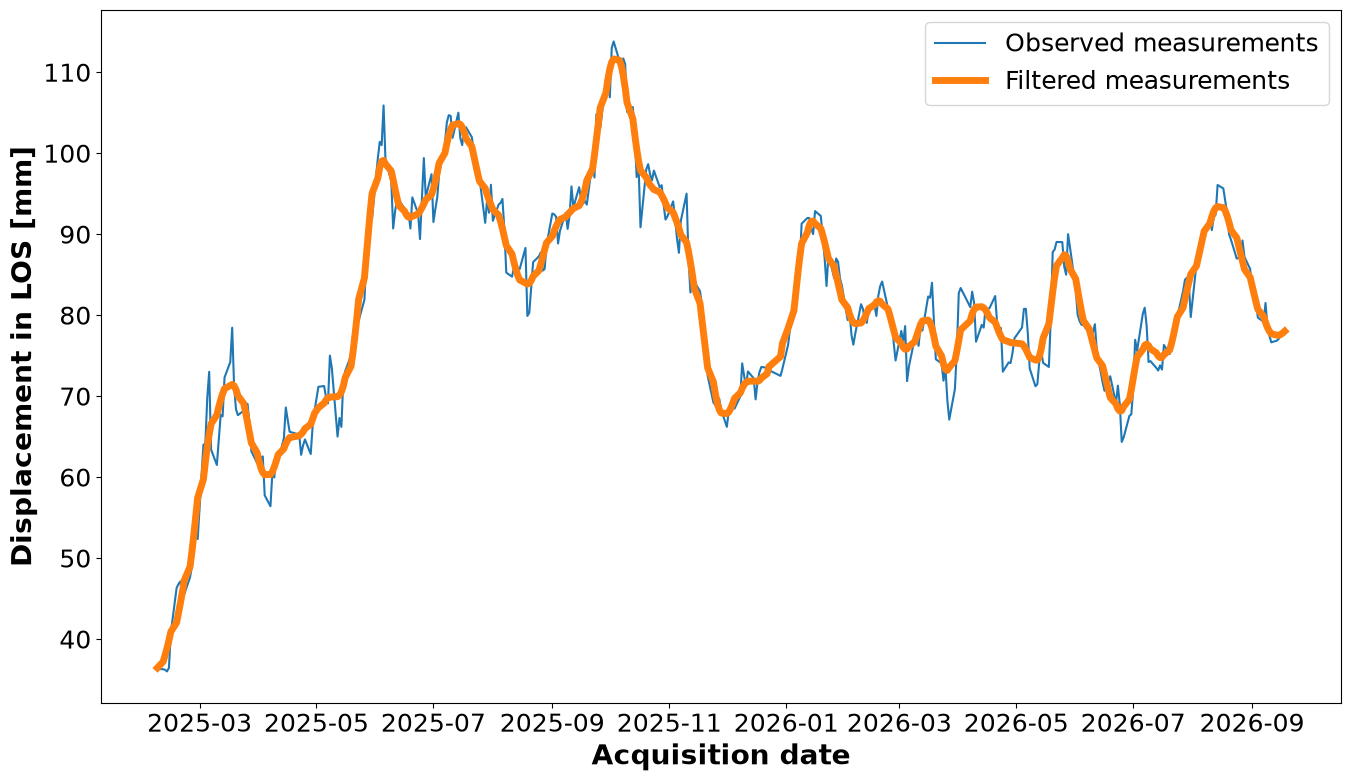

In [9]:
from scipy import signal

omega_g = 1./90      #cut off frequency
fs      = 1./6     

this_omega_g = omega_g
sos = signal.butter(3, this_omega_g, 'lp', fs=fs, output='sos')
this_signal_filtered = signal.sosfiltfilt(sos, this_signal)

plt.figure(figsize=[16,9])
plt.plot(time, this_signal, label='Observed measurements')
plt.plot(time, this_signal_filtered, linewidth=5, label='Filtered measurements')

this_signal = this_signal_filtered
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)


In [10]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer, *, shuffle=True):
    """Generates dataset windows

    Args:
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method
      shuffle(bool) - shuffle training windows; disable for validation

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """
  
    if window_size < 1 or batch_size < 1:
        raise ValueError("window_size and batch_size must be positive.")
    n_windows = len(series) - window_size
    if n_windows <= 0:
        raise ValueError("The series must contain more values than window_size.")

    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)
    
    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    
    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Create tuples with features and labels 
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Shuffle the windows
    if shuffle:
        dataset = dataset.shuffle(shuffle_buffer)
    
    # Create batches of windows
    dataset = dataset.batch(batch_size)
    # flat_map loses the known length. Include the final partial batch so
    # Keras can end each epoch without probing past the dataset's end.
    n_batches = (n_windows + batch_size - 1) // batch_size
    dataset = dataset.apply(tf.data.experimental.assert_cardinality(n_batches))
    dataset = dataset.prefetch(1)
    
    return dataset

## **Split dataset**

In [11]:
# Chronological split of the selected (filtered) input series.
train_end = 270
split_time = 340  # Test starts here; validation ends immediately before it.
if len(time) != len(this_signal):
    raise ValueError("Time and signal must have the same length.")
if not window_size < train_end < split_time < len(this_signal):
    raise ValueError("Require training windows and non-empty validation/test segments.")

time_train = time[:train_end]
x_train = this_signal[:train_end]
time_valid = time[train_end:split_time]
x_valid = this_signal[train_end:split_time]
time_test = time[split_time:]
x_test = this_signal[split_time:]


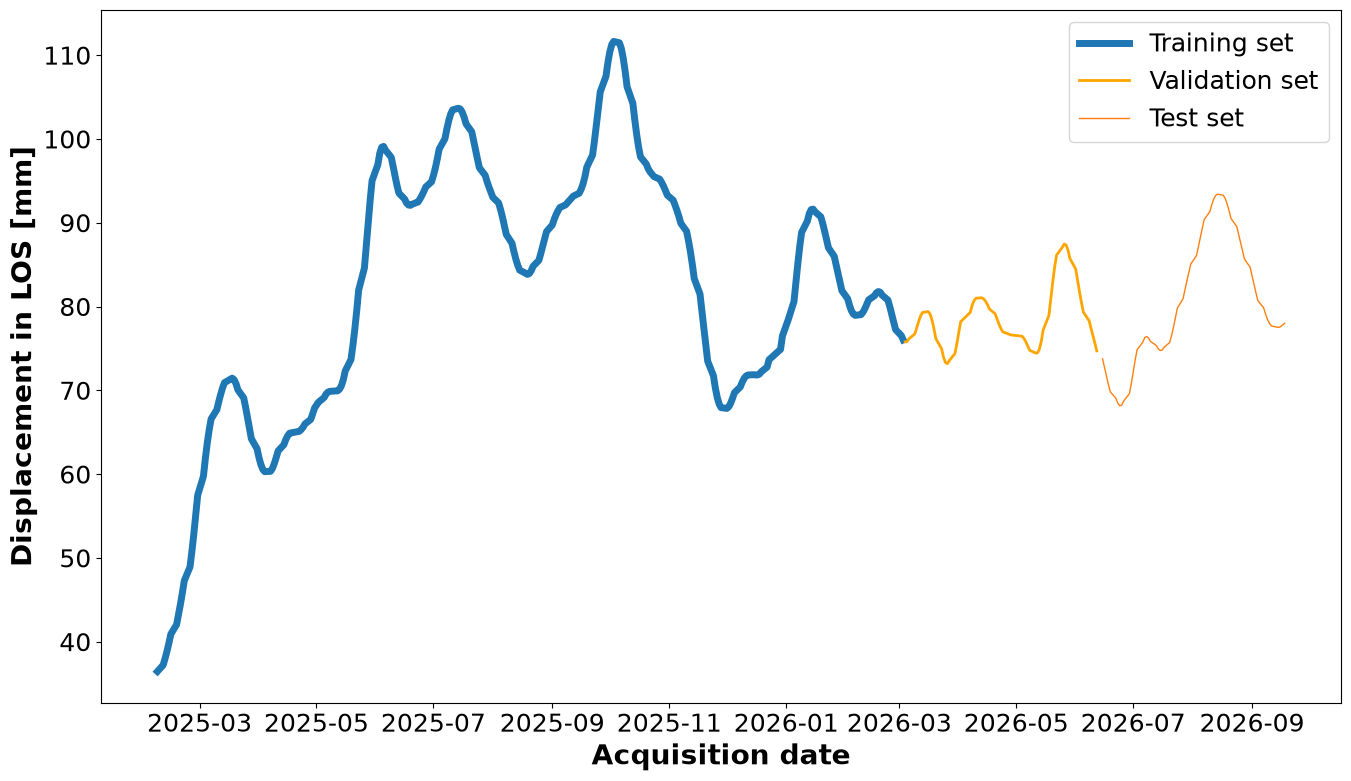

In [12]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, linewidth=5, label='Training set')
plt.plot(time_valid, x_valid, linewidth=2, color='orange', label='Validation set')
plt.plot(time_test, x_test, linewidth=1, label='Test set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

In [13]:
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer)

# Prepend past observations so the first validation target is train_end.
# Every target lies in [train_end, split_time); inputs precede their target.
valid_series = this_signal[train_end - window_size:split_time]
valid_set = windowed_dataset(
    valid_series, window_size, batch_size, shuffle_buffer, shuffle=False,
)


# The AI-part

## The model [2]

There's another model at the end of this notebook: the "Sunspot model" from Coursera's Tensorflow Time Series Course (where this is taken from, too).

In [14]:
# Build the architecture once as a factory for independent models.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

def build_model():
    return tf.keras.models.Sequential([
        tf.keras.Input(shape=(window_size, 1)),
        tf.keras.layers.Conv1D(
            filters=64, kernel_size=3, strides=1,
            padding="causal", activation="relu",
        ),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(1),
        tf.keras.layers.Lambda(lambda x: x * 20.),
    ])

model = build_model()
# Both the LR test and actual training start from these untrained weights.
initial_weights = [weight.copy() for weight in model.get_weights()]


In [15]:
#model = tf.keras.models.load_model('./model/experiment001/')

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

### 2.1 Lernraten-Test mit Adam und MSE

Die nächsten beiden Zellen testen dieselbe Architektur, denselben Adam-Optimierer
und denselben MSE-Loss wie das eigentliche Training. Zuerst die Modellaufbau-Zelle
ausführen: Sie speichert einen reproduzierbaren, untrainierten Ausgangszustand.

Der Suchlauf trainiert ausschließlich `lr_model` auf den Trainingsdaten. Das
vorhandene `model` bleibt unverändert. Die Gewichte und der Adam-Zustand des
Suchlaufs werden anschließend nicht für das eigentliche Training übernommen.

Die Lernrate steigt innerhalb eines zusammenhängenden Trainingslaufs von `1e-6`
bis `1e-2`. Jeder Kurvenpunkt ist der durchschnittliche Trainings-MSE einer Epoche;
die Punkte sind keine unabhängigen Trainingsversuche. Der Kurvenverlauf liefert
einen Kandidatenbereich, keine garantiert optimale Lernrate. Eine gewählte Rate
sollte zusätzlich anhand zeitlich nachgelagerter Validierungsdaten geprüft werden.


In [17]:
from IPython.display import DisplayHandle, HTML


class TrainingAnzeige(tf.keras.callbacks.Callback):
    """Aktualisiert zwei Ausgabezeilen nach jeder abgeschlossenen Epoche."""

    def on_train_begin(self, logs=None):
        self.anzeige = DisplayHandle()
        self.anzeige.display(self.inhalt(0, "–"))

    def on_epoch_end(self, epoch, logs=None):
        loss = (logs or {}).get("loss")
        loss_text = f"{loss:.6f}" if loss is not None else "–"
        val_loss = (logs or {}).get("val_loss")
        self.anzeige.update(self.inhalt(epoch + 1, loss_text, val_loss))

    def inhalt(self, epoche, loss, val_loss=None):
        lernrate = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        validation_text = (
            f" | Validierungs-Loss: {val_loss:.6f}" if val_loss is not None else ""
        )
        text = (
            f"Epoche: {epoche} / {self.params['epochs']}\n"
            f"Trainings-Loss: {loss}{validation_text} | Lernrate: {lernrate:.3g}"
        )
        return HTML(f"<pre>{text}</pre>")


# Learning-rate range test: independent model, fresh Adam, same MSE loss.
LR_MIN = 1e-6
LR_MAX = 1e-2
LR_EPOCHS = 100
if not 0 < LR_MIN < LR_MAX or LR_EPOCHS < 2:
    raise ValueError("Require 0 < LR_MIN < LR_MAX and at least two epochs.")

lr_values = np.geomspace(LR_MIN, LR_MAX, LR_EPOCHS)
lr_train_set = train_set.map(
    lambda x, y: (
        tf.cast(x[..., tf.newaxis], tf.float32),
        tf.cast(y[..., tf.newaxis], tf.float32),
    )
)
lr_model = build_model()
lr_model.set_weights(initial_weights)
lr_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_MIN),
    loss="mse",
)
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch, current_lr: float(lr_values[epoch])
)

lr_history = lr_model.fit(
    lr_train_set,
    epochs=LR_EPOCHS,
    callbacks=[lr_schedule, tf.keras.callbacks.TerminateOnNaN(), TrainingAnzeige()],
    shuffle=False,  # train_set already shuffles its windows
    verbose=0,
)
# Account for an early stop on a non-finite loss.
lrs = lr_values[:len(lr_history.history["loss"])]


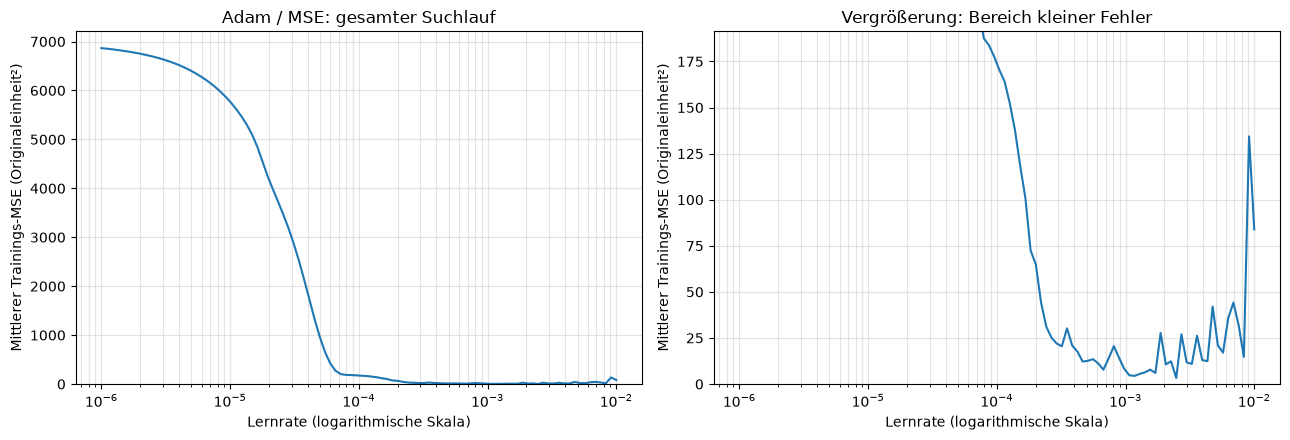

Kleinster protokollierter Trainings-MSE: 3.26057
Lernrate an diesem Punkt: 0.00248
Dies ist keine automatisch validierte optimale Lernrate.
Die Rate für das eigentliche Training wird in der nächsten Codezelle gesetzt.


In [18]:
# X: logarithmic learning rate; Y: linear mean training MSE.
lr_losses = np.asarray(lr_history.history["loss"], dtype=float)
finite = np.isfinite(lr_losses)
if not finite.any():
    raise ValueError("No finite losses recorded; check the data and LR_MIN.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax in axes:
    ax.semilogx(lrs, lr_losses)
    ax.set_xlabel("Lernrate (logarithmische Skala)")
    ax.set_ylabel("Mittlerer Trainings-MSE (Originaleinheit²)")
    ax.grid(True, which="both", alpha=0.35)
axes[0].set_title("Adam / MSE: gesamter Suchlauf")
axes[0].set_ylim(bottom=0)

# Zoom into the lower-loss region without a fixed, data-dependent scale of 0–50.
zoom_upper = max(float(np.median(lr_losses[finite])) * 1.1, np.finfo(float).eps)
axes[1].set_ylim(0, zoom_upper)
axes[1].set_title("Vergrößerung: Bereich kleiner Fehler")
plt.tight_layout()
plt.show()

best_index = np.flatnonzero(finite)[np.argmin(lr_losses[finite])]
print(f"Kleinster protokollierter Trainings-MSE: {lr_losses[best_index]:.6g}")
print(f"Lernrate an diesem Punkt: {lrs[best_index]:.3g}")
print("Dies ist keine automatisch validierte optimale Lernrate.")
print("Die Rate für das eigentliche Training wird in der nächsten Codezelle gesetzt.")


# Train the model

`learning_rate` unten ist die Rate für das eigentliche Training. Der bisherige
Wert `1e-3` bleibt als Ausgangswert stehen; der Suchlauf überschreibt ihn nicht.
Nach Betrachtung der Kurve kann hier ein Kandidat aus einem stabilen Bereich
eingetragen werden.

Diese Zelle setzt die Modellgewichte auf den gespeicherten untrainierten
Ausgangszustand zurück und verwendet einen neuen Adam-Optimierer. Ein erneuter
Aufruf startet daher ein neues Training. `history` enthält dessen Verlauf;
`lr_history` bleibt ausschließlich dem Lernraten-Test zugeordnet.


In [19]:
# Set the candidate learning rate after inspecting the separate LR test.
learning_rate = 8.9e-4

# Match the model's expected shapes:
# inputs: [batch, window_size, 1], targets: [batch, 1]
train_set_3d = train_set.map(
    lambda x, y: (
        tf.cast(x[..., tf.newaxis], tf.float32),
        tf.cast(y[..., tf.newaxis], tf.float32),
    )
)

# Same shapes and dtype as training, with chronological validation windows.
valid_set_3d = valid_set.map(
    lambda x, y: (
        tf.cast(x[..., tf.newaxis], tf.float32),
        tf.cast(y[..., tf.newaxis], tf.float32),
    )
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=20,
    restore_best_weights=True,
)

# Restart with untrained weights and a fresh optimizer, never the sweep state.
model.set_weights(initial_weights)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="mse",
)

history = model.fit(
    train_set_3d,
    validation_data=valid_set_3d,
    epochs=400,
    shuffle=False,  # train_set already shuffles its windows
    verbose=0,
    callbacks=[early_stopping, TrainingAnzeige()],
)


## Now, let's make some predictions

In [20]:

# Initialize a list
forecast = []

# Reduce the original series
forecast_series = this_signal[split_time - window_size:]

# Use the model to predict data points per window size
for time1 in range(len(forecast_series) - window_size):
  forecast.append(model.predict(forecast_series[time1:time1 + window_size][np.newaxis], verbose=0))

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()



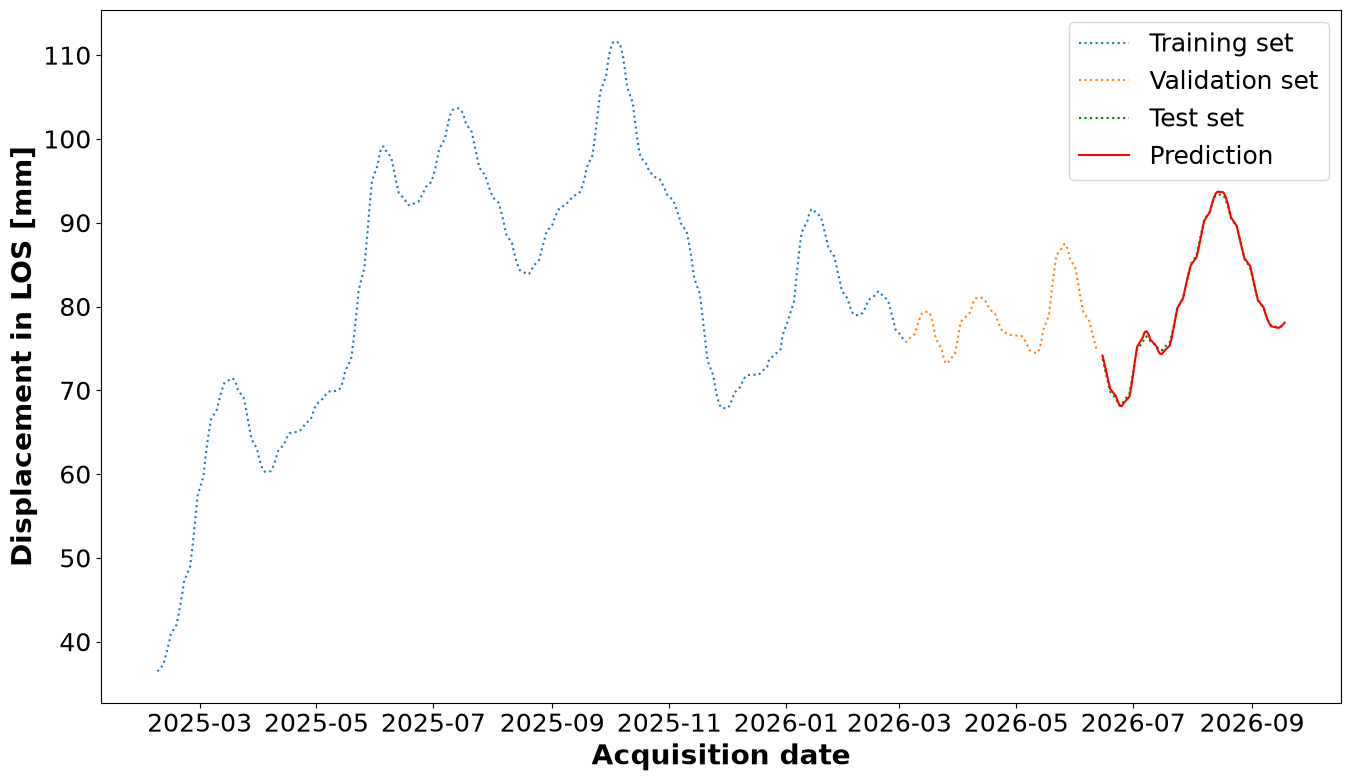

In [21]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, ':', label='Training set')
plt.plot(time_valid, x_valid, ':', label='Validation set')
plt.plot(time_test, x_test, ':', color='green', label='Test set')
plt.plot(time_test, results,'-',color='red', label='Prediction')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.savefig('pred.png')

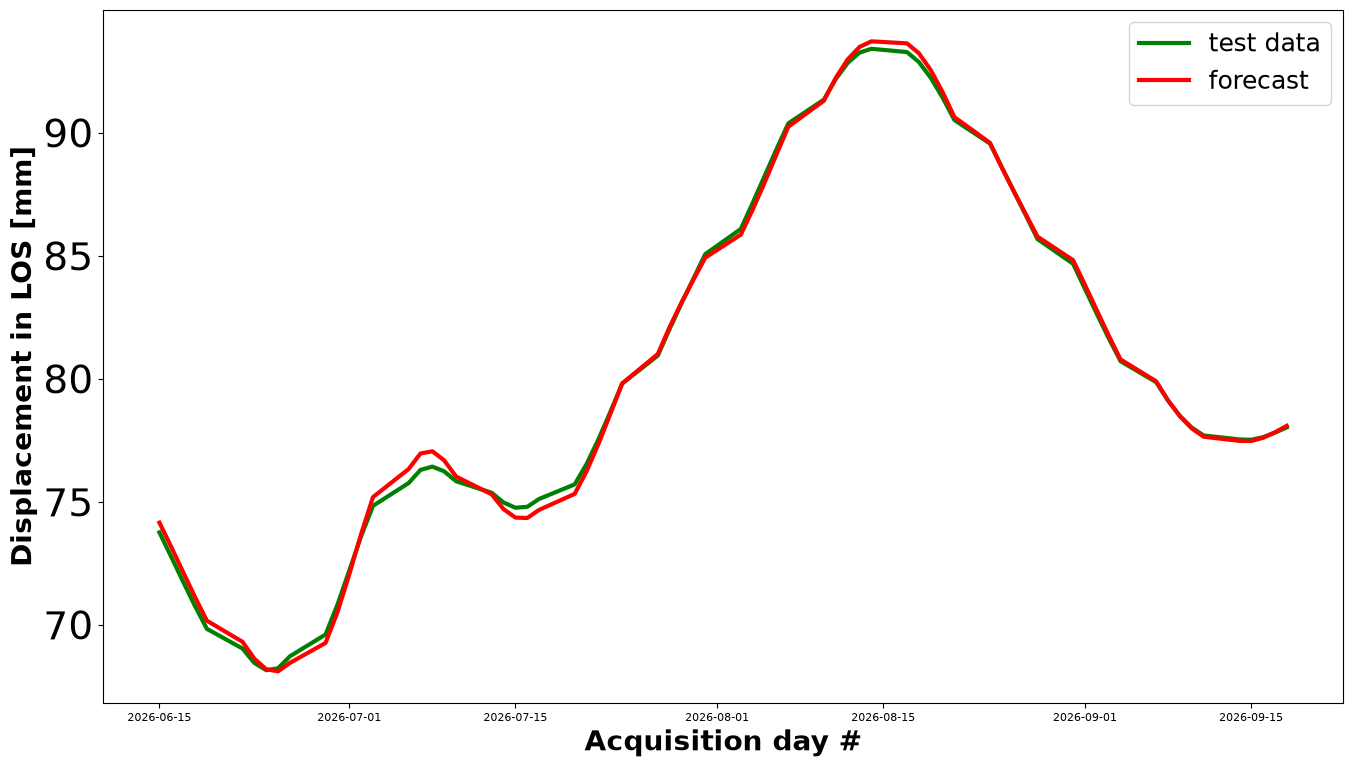

In [22]:
# Plot the train set
plt.figure(figsize=[16,9])
#plt.plot(time_train, x_train)

plt.plot(time_test, x_test, color='green', linewidth=3, label= 'test data')
plt.plot(time_test, results, color='red', linewidth=3, label='forecast')
plt.legend()
#plt.xlim([2000,2600])
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition day #', fontsize=20, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)

In [23]:
# Compute the metrics

print("MSE:", tf.keras.metrics.MeanSquaredError()(x_test, results).numpy())
print("MAE:", tf.keras.metrics.MeanAbsoluteError()(x_test, results).numpy())

MSE: 0.06550196
MAE: 0.198498


# Own Predictions

What happens, if we use our predictions as input for further predictions

In [24]:
# Own predictions
# Direct inference avoids predict() traces cached with a different input rank.
future_steps = 15
own_forecast = []

# Keep rolling one-step predictions over the test period using observed data.
forecast_series = np.asarray(this_signal[split_time - window_size:], dtype=np.float32)
for start in range(len(forecast_series) - window_size):
    input_window = forecast_series[start:start + window_size]
    prediction = model(
        tf.convert_to_tensor(input_window.reshape(1, window_size, 1), dtype=tf.float32),
        training=False,
    ).numpy()
    own_forecast.append(float(np.asarray(prediction).reshape(-1)[0]))

# Beyond the observations, feed each prediction back into the next window.
future_window = np.asarray(this_signal[-window_size:], dtype=np.float32).copy()
future_forecast = []
for step in range(future_steps):
    prediction = model(
        tf.convert_to_tensor(future_window.reshape(1, window_size, 1), dtype=tf.float32),
        training=False,
    ).numpy()
    next_value = float(np.asarray(prediction).reshape(-1)[0])
    future_forecast.append(next_value)
    future_window = np.append(future_window[1:], np.float32(next_value))

# Separate names preserve the existing test-only results and metric/plot lengths.
own_test_results = np.asarray(own_forecast)
future_results = np.asarray(future_forecast)
own_results = np.concatenate([own_test_results, future_results])

print("Vorhersagen über das Ende des Testzeitraums hinaus:")
for step, value in enumerate(future_results, start=1):
    print(f"Schritt +{step}: {value:.6f}")


Vorhersagen über das Ende des Testzeitraums hinaus:
Schritt +1: 78.330589
Schritt +2: 78.654541
Schritt +3: 79.019608
Schritt +4: 79.376930
Schritt +5: 79.730797
Schritt +6: 80.054771
Schritt +7: 80.345306
Schritt +8: 80.587494
Schritt +9: 80.776100
Schritt +10: 80.902596
Schritt +11: 80.965302
Schritt +12: 80.960854
Schritt +13: 80.891235
Schritt +14: 80.757973
Schritt +15: 80.566406


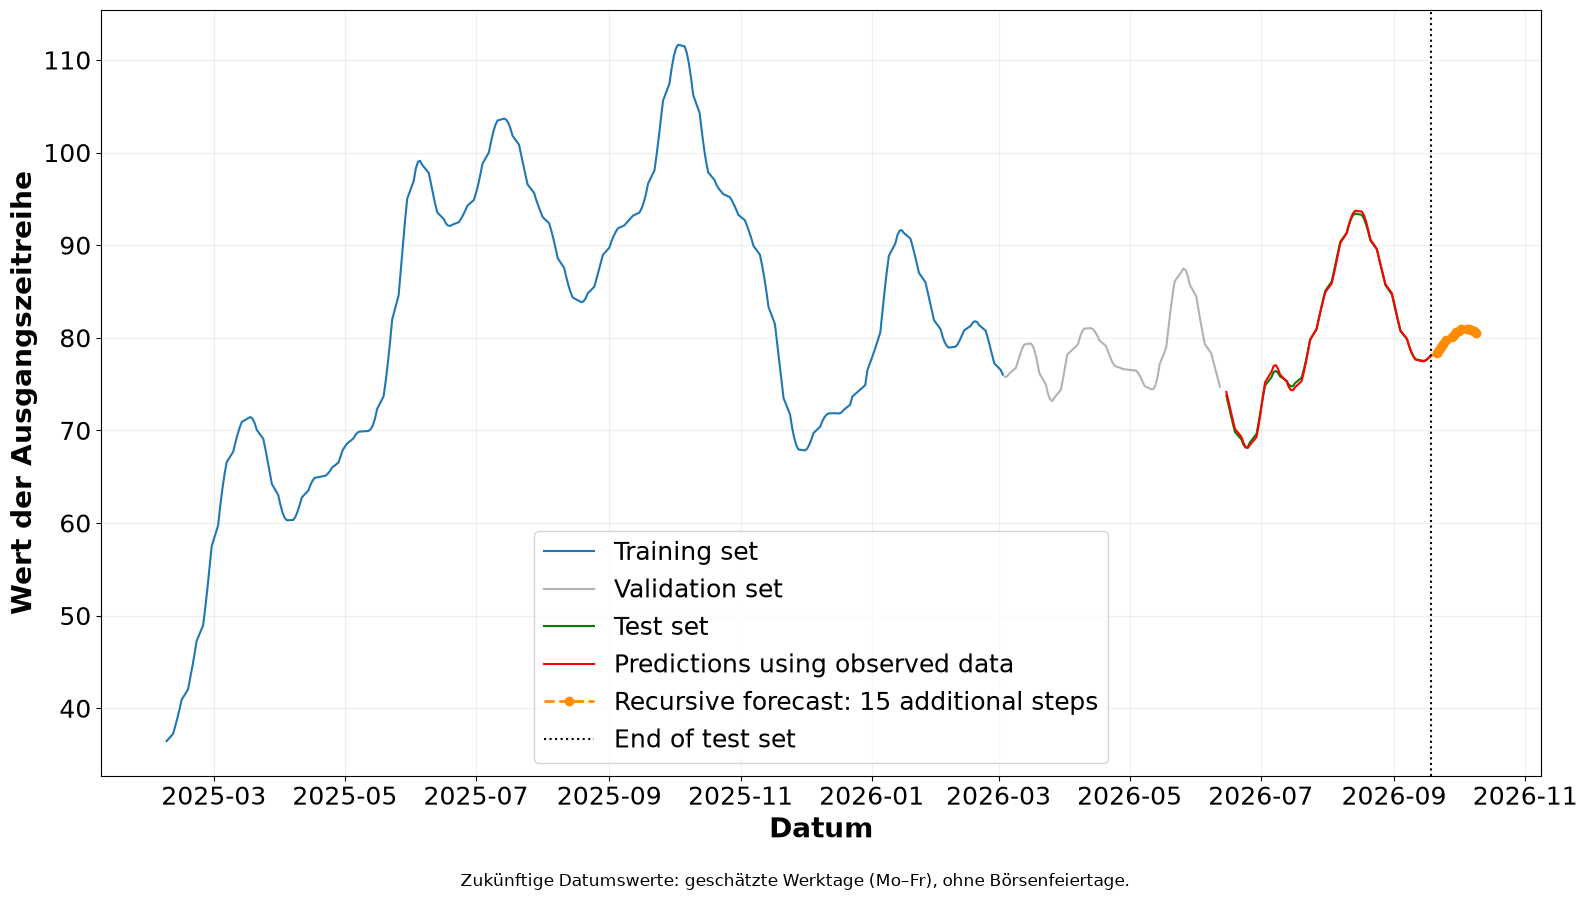

In [25]:
# Plot own predictions, including the forecast beyond the test period.
# For the current daily stock series, future dates are estimated weekdays.
# This is not an exchange calendar: public holidays are not excluded.
future_time = pd.bdate_range(
    start=pd.Timestamp(time_test[-1]) + pd.offsets.BDay(1),
    periods=len(future_results),
)

plt.figure(figsize=[16, 9])
plt.plot(time_train, x_train, label='Training set')
plt.plot(time_valid, x_valid, color='gray', alpha=0.6, label='Validation set')
plt.plot(time_test, x_test, color='green', label='Test set')
plt.plot(
    time_test, own_test_results, color='red',
    label='Predictions using observed data',
)
# Anchor the future segment at the last observation used for its first input.
future_plot_time = pd.DatetimeIndex([time_test[-1]]).append(future_time)
future_plot_values = np.concatenate([[x_test[-1]], future_results])
plt.plot(
    future_plot_time, future_plot_values, color='darkorange',
    linestyle='--', marker='o', markevery=list(range(1, len(future_plot_values))),
    linewidth=2,
    label=f'Recursive forecast: {len(future_results)} additional steps',
)
plt.axvline(time_test[-1], color='black', linestyle=':', label='End of test set')
plt.ylabel('Wert der Ausgangszeitreihe', fontsize=20, fontweight='bold')
plt.xlabel('Datum', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(alpha=0.2)
plt.figtext(
    0.5, 0.01,
    'Zukünftige Datumswerte: geschätzte Werktage (Mo–Fr), ohne Börsenfeiertage.',
    ha='center', fontsize=12,
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


Oben: Das sieht aus, als ob sich auch auf Basis nativer Vorhersagen wenigstens 30 Werte gut vorhersagen lassen. Das wären immerhin 180 Tage. Wir filtern bei 90 Tagen. Das ist das Mindestmaß, das wir berücksichtigen können müssen, entsprechend sind das 15 Werte. Danach müsste das Modell nachgesteuert werden.


## Annotations and References

[2] All models here are adopted form Model adopted from https://www.coursera.org/learn/tensorflow-sequences-time-series-and-prediction?specialization=tensorflow-in-practice


## Intro to Machine Learning

https://opencampus.sh F.O.C + super good + hybrid! + you gain 2.5/5 ECTS



